In [1]:
import numpy as np
from scipy.fft import fft, fftfreq, fftshift, fft2
import matplotlib.pyplot as plt
import os
import sys

sys.path.append('../../')
from vysxd_define import *
from vysxd_analysis import *

# Thermal fluctuations in a two-ion species plasma
Checking for consistency with theoretical dispersion relation

In [5]:
electrons1_path = '/mnt/DATA/DATA1/mattketk/brillouin-multispecies/thermal_fluctuations2/MS/DENSITY/electrons/charge/'
# electrons2_path = '/mnt/DATA/DATA1/mattketk/brillouin-multispecies/thermal_fluctuations2/MS/DENSITY/electrons2/charge/'
ion1_path = '/mnt/DATA/DATA1/mattketk/brillouin-multispecies/thermal_fluctuations2/MS/DENSITY/ion1/charge/'
# ion2_path = '/mnt/DATA/DATA1/mattketk/brillouin-multispecies/thermal_fluctuations2/MS/DENSITY/ion2/charge/'
n_e1, dt, dx, t, x = get_osiris_quantity_1d(electrons1_path)
# n_e2, dt, dx, t, x = get_osiris_quantity_1d(electrons2_path)
n_i1, dt, dx, t, x = get_osiris_quantity_1d(ion1_path)
# n_i2, dt, dx, t, x = get_osiris_quantity_1d(ion2_path)

# n_tot = -n_e1 - n_e2 + n_i1 + n_i2
n_tot = -n_e1 + n_i1
# n_tot = n_i1

/tmp/ipykernel_344549/1523886559.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


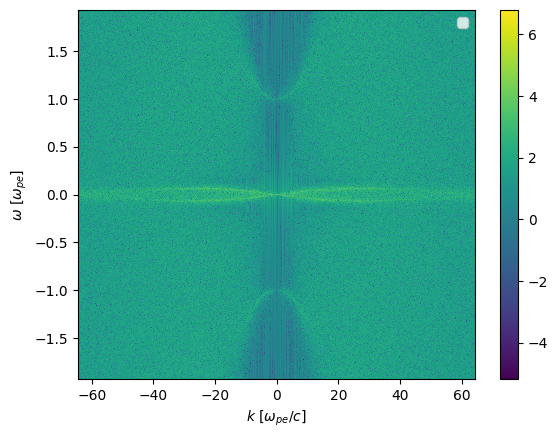

In [6]:
w2 = 2*np.pi * fftshift(fftfreq(n_tot.shape[0], d=dt), axes=0) 
k2 = 2*np.pi * fftshift(fftfreq(n_tot.shape[1], d=dx), axes=0)
ewk = fftshift(np.real(fft2(n_tot)))
# ewk2 = np.ma.array(ewk*np.conj(ewk), mask=(ewk*np.conj(ewk)<10))
# ewk2 = ewk*np.conj(ewk)
# plt.pcolormesh(k2, w2, np.log10(np.abs(ewk)), vmin=-4, vmax=2)
plt.pcolormesh(k2, w2, np.log10(np.abs(ewk)))
# plt.xlim([0., 7.5])
# plt.ylim([0., 5e-2])
# plt.ylim([0., 9.5e-2])

# plt.plot([0.275, 0.300], [0.085, 0.065], color='r', ls='--', label='Plasma: $v_g\\sim 0.86c$')
# plt.plot([0.313, 0.338], [0.090, 0.065], color='b', ls='--', label='Vacuum: $v_g\\sim c$')
plt.legend()

plt.ylabel(r'$\omega$ [$\omega_{pe}$]')
plt.xlabel(r'$k$ [$\omega_{pe}/c$]')
plt.colorbar()


In [7]:
e1_path = '/mnt/DATA/DATA1/mattketk/brillouin-multispecies/thermal_fluctuations2/MS/FLD/e1/'
e1, dt, dx, t, x = get_osiris_quantity_1d(e1_path)

In [23]:
# importing from DispersionSolver.ipynb
kbkb = np.load('/home/mattketk/rotw/data/kbkb.npy')
w_2ion_ub = np.load('/home/mattketk/rotw/data/w_2ion_ub.npy')
w_2ion_lb1 = np.load('/home/mattketk/rotw/data/w_2ion_lb1.npy')

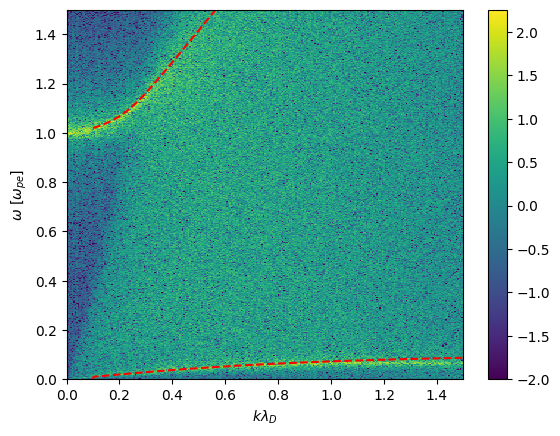

In [27]:
v_the = 0.04424

w2 = 2*np.pi * fftshift(fftfreq(e1.shape[0], d=dt), axes=0) 
k2 = v_the * 2*np.pi * fftshift(fftfreq(e1.shape[1], d=dx), axes=0)
ewk = fftshift(np.real(fft2(e1)))
# ewk2 = np.ma.array(ewk*np.conj(ewk), mask=(ewk*np.conj(ewk)<10))
# ewk2 = ewk*np.conj(ewk)
# plt.pcolormesh(k2, w2, np.abs(ewk))
plt.pcolormesh(k2, w2, np.log10(np.abs(ewk)), vmin=-2)
plt.plot(kbkb, w_2ion_lb1, ls='--', c='r')
plt.plot(kbkb, w_2ion_ub, ls='--', c='r')
plt.xlim([0., 1.5])
plt.ylim([0., 1.5])

# plt.plot([0.275, 0.300], [0.085, 0.065], color='r', ls='--', label='Plasma: $v_g\\sim 0.86c$')
# plt.plot([0.313, 0.338], [0.090, 0.065], color='b', ls='--', label='Vacuum: $v_g\\sim c$')
# plt.legend()

plt.ylabel(r'$\omega$ [$\omega_{pe}$]')
plt.xlabel(r'$k\lambda_D$')
plt.colorbar()

plt.savefig('/home/mattketk/rotw/figures/dispersion_1ion_agreement.png', dpi=200)

In [29]:
kbkb[::len(kbkb)//10]

array([0.1       , 0.24014014, 0.38028028, 0.52042042, 0.66056056,
       0.8007007 , 0.94084084, 1.08098098, 1.22112112, 1.36126126])

In [31]:
w_2ion_lb1[::len(w_2ion_lb1)//10].real

array([0.        , 0.02363658, 0.03606714, 0.04698168, 0.05627852,
       0.06405374, 0.0705087 , 0.07587614, 0.08037716, 0.08420305])

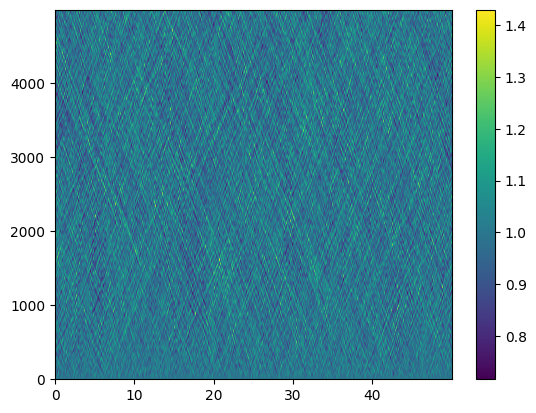

In [45]:
plt.pcolormesh(x, t, n_tot)
plt.colorbar()